<h1><strong>Advanced Topics in Financial Modelling - S&P 500 and Strategy Analysis</strong></h1>

<p><strong>Author:</strong> Anjali PANARAKOTTIL VIJAYAN & Aminata BARRY, M2 IRFA Université Paris 1 Panthéon Sorbonne </p>
<p><strong>Course:</strong> Advanced Topics in Financial Modelling - Nicolas GAUSSEL</p>
<p><strong>Date:</strong> 27 April 2026</p>

<h1><strong>Workflow</strong></h1>

1. **Data retrieval** : S&P 500 (dividend reinvested) and a synthetic USD bank account built from Fed Funds rates.
2. **Descriptive statistics** : full sample (1976+) and post-2010 sub-sample.
3. **Black&ndash;Scholes proxy testing** : can a constant-volatility geometric-Brownian-motion model describe the price process?
4. **Constant-mix strategy**: derivation, simulation, and decomposition into *Option Profile + Trading Impact*.
5. **Doubling ("when in trouble, double") strategy** - theoretical solution and simulation.

In this notebook any portfolio strategy of the form $dV_t = f(S_t)\, dS_t$ admits the decomposition
$$
V_t - V_0 \;=\; \underbrace{F(S_t) - F(S_0)}_{\text{Option profile}}\;-\;\underbrace{\tfrac12 \int_0^t f'(S_s)\, S_s^2\, \sigma_s^2 \, ds}_{\text{Trading impact}}
$$ 
which lets us read every dynamic strategy as a static option payoff plus a path-dependent gamma cost.


<h1>1.Data Fetching<h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
import seaborn as sns 
from scipy import stats
import statsmodels.api as sm

In [2]:
# Importing Market data
import yfinance as yf
import datetime as dt

In [3]:
np.random.seed(42)#seed for simulations
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [4]:
# Plot style 
sns.set_theme(style='whitegrid', context='notebook')
PALETTE = ['#1a4365', '#c05621', '#2c7a7b', '#702459', '#744210', '#22543d']
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.figsize':     (11, 4.5),
    'figure.dpi':         110,
    'axes.titleweight':   'bold',
    'axes.titlesize':     12,
    'axes.labelsize':     10,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'grid.alpha':         0.3,
    'legend.frameon':     False,
})

N_PER_YEAR = 252  # trading days per year

<h1>2.S&P 500 Data Retrieval<h1>


We pull the **dividend-reinvested S&P 500** since 1976 via yfinance's Adj Close column, which corresponds to a self-financing investor who reinvests every coupon on its payment date.We have used the the natural total-return process S(t)S(t)
S(t) plus ignoring dividends would shave a substantial portion of the cumulative return over fifty years and bias every subsequent estimate of $\mu$ and the Sharpe ratio. 

We disable auto_adjust so that the raw Close and the dividend adjusted Adj Close remain as separate columns. 
Their difference will let us recover the dividend yield later without an external feed.

Here we have also flattened the occasional MultiIndex that yfinance returns for singleticker queries.Finally we rescale to S(t0)=1S(t_0) = 1, S(t0​)=1, so that S(t)S(t), S(t) reads directly as the gross return of one unit of currency invested at t0t_0
t0​ a normalisation that keeps the dynamic strategy formulas of the later sections numerically clean and easy to interpret as multiples of the initial investment.


In [5]:
raw=yf.download('^GSPC', start='1976-01-01', end=dt.datetime.today(), progress=False,auto_adjust=False)
#Handle potential multi-index columns if ever present (like ticker,field - ex.("AAPL", "Open")) 
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0) #detects if the column names have a “double” structure and, if so, it simplifies them to a simple string instead of tuples. 

sp = raw[['Adj Close']].rename(columns={'Adj Close': 'S'}).copy()#extration of the adjusted close and renaming it S 
#rescaling and normalizing the baseline price to 1
sp['S'] = sp['S'] / sp['S'].iloc[0] 
sp['Close']=raw['Close']/raw['Close'].iloc[0] #price only, no dividends so as for the isolation of the divident yeild 


print(f'S&P series spans {sp.index[0].date()} to {sp.index[-1].date()} '
      f'({len(sp):,} business days)')
sp.head(3)

S&P series spans 1976-01-02 to 2026-04-24 (12,683 business days)


Price,S,Close
Date,,
1976-01-02,1.0000,1.0000
1976-01-05,1.0185,1.0185
1976-01-06,1.0289,1.0289


<h1>3.Building a USD Bank Account<h1>



We build a **USD bank account** $B(t)$ from the **effective Federal Funds rate** (FRED series DFF), which is the overnight rate at which U.S. banks lend reserves to each other, the closest empirical proxy to the riskfree short rate $r(t)$ that is in the Black&Scholes framework. 

This is the natural numéraire for our dynamic strategies ie every closed form expression discussed below is written on the *discounted* scale $\tilde{S}(t) = S(t)/B(t)$, where the bank account absorbs the time value of money and only the risky asset's excess dynamics remain.

We pulled the daily rate directly from FRED's CSV endpoint, parse the observation_date column as datetimes, rename to a cleaner schema (date, r), and **convert from percent to decimal** by dividing by 100. The errors='coerce' flag turns any non num entries (FRED occasionally inserts a '.' for missing observations) into NaN rather than raising, these gaps will be forwardfilled in the next step when we align with the S&P trading day calendar.



In [6]:
fred_url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF' #extracting the Federal Funds Rate data from FRED
fed = pd.read_csv(fred_url, parse_dates=['observation_date'])
fed = fed.rename(columns={'observation_date': 'date', 'DFF': 'r'}).set_index('date')
fed['r'] = pd.to_numeric(fed['r'], errors='coerce') / 100.0  # conversion from percent to decimal for r and handle non num values




Next we  **align the rate series with the S&P trading calendar** via a left join, then forward fill any gaps so that every business day inherits the most recently published rate this handles weekends, holidays, and the occasional missing FRED observation, and reflects the practical reality that an investor earns the prevailing overnight rate until the central bank announces a new one.

The bank account is built by **discrete compounding day by day**:
$$
B(t_{i+1}) = B(t_i)\bigl(1 + r(t_i)\, \Delta t_i\bigr), \qquad B(t_0) = 1,
$$
where $\Delta t_i$ is the *actual* fraction of a year between consecutive observations (computed as calendar days divided by 365.25 to absorb leap years). This is important because trading-day gaps are not uniform a Friday to Monday step covers three calendar days of accrued interest, not one and using the day count $\Delta t_i$ rather than a flat $1/252$ keeps $B(t)$ consistent with how money market interest is actually paid.

We use the rate prevailing at the **start** of each interval (r.shift()) rather than at the end, which is the correct convention for forward accrued interest: the rate is set today and earned over tomorrow's gap. Finally we pin $B(t_0) = 1 $ exactly so that $B(t)$ reads directly as the gross return of one unit of currency held in cash  making the discounted ratio $\tilde S(t) = S(t)/B(t)$ a clean, dimensionless quantity that we will use throughout the dynamic strategy sections.



In [7]:
#Joining the S&P data with the Federal Funds Rate data 
df = sp.join(fed, how='left')
df['r'] = df['r'].ffill()# ensuring each day has an intrest rate via forward fill
df = df.dropna(subset=['S', 'r']).copy()

# Average dt 'in years' between rows of our trading day index 
delta_days = df.index.to_series().diff().dt.days
dt_yrs     = delta_days / 365.25 # fraction of a year between consecutive observations
dt_avg     = dt_yrs.mean()

# Compound daily returns
# using yesterday's rate over today's gap ie . rate at the beginning of the interval).
df['B'] = (1 + df['r'].shift().fillna(0) * dt_yrs.fillna(0)).cumprod()
df.loc[df.index[0], 'B'] = 1.0  # ensure exact start at 1

print(f'Average dt between rows: {dt_avg:.5f} years (~{dt_avg*365.25:.2f} calendar days)')
print(f'Final bank-account value: {df["B"].iloc[-1]:.2f} starting from 1 in {df.index[0].year}')
df.head(3)

Average dt between rows: 0.00397 years (~1.45 calendar days)
Final bank-account value: 10.40 starting from 1 in 1976


,S,Close,r,B
Date,,,,
1976-01-02,1.0000,1.0000,0.0528,1.0000
1976-01-05,1.0185,1.0185,0.0529,1.0004
1976-01-06,1.0289,1.0289,0.0505,1.0006




In the code block that follows we **plot $S(t)$ and $B(t)$ side by side on a log-scale**, the natural display for processes that grow geometrically: under the Black and Scholes framework $\ln S(t)$ is approximately linear in $t$ with slope $\mu$ minus half sigma squared, so a log-scaled total-return series should look like a straight line with random fluctuations around it.

To give the eye a sense of where the volatility shocks are concentrated, we overlay four shaded bands corresponding to the major equity drawdowns of the period: **Black Monday in October 1987, the dot com bust of 2000 to 2003, the Global Financial Crisis of 2007 to 2009, and the COVID 19 crash of early 2020**. These are the windows where a constant volatility assumption breaks most visibly, and they will reappear in section 3 as outliers in the residuals of our variance regression. The bank account $B(t)$, by contrast, has no such episodes since it is monotone by construction; what we see instead is a slope that visibly steepens during the high rate Volcker years of the early 1980s and flattens after 2009 when the Fed pinned rates near zero.

The headline number printed below the chart, the ratio of final $S$ to final $B$, summarises **the cumulative excess return of equities over cash** over fifty years. A figure substantially above one is the empirical signature of the **equity risk premium**: the long-run reward investors have historically earned for bearing the volatility we are about to study.



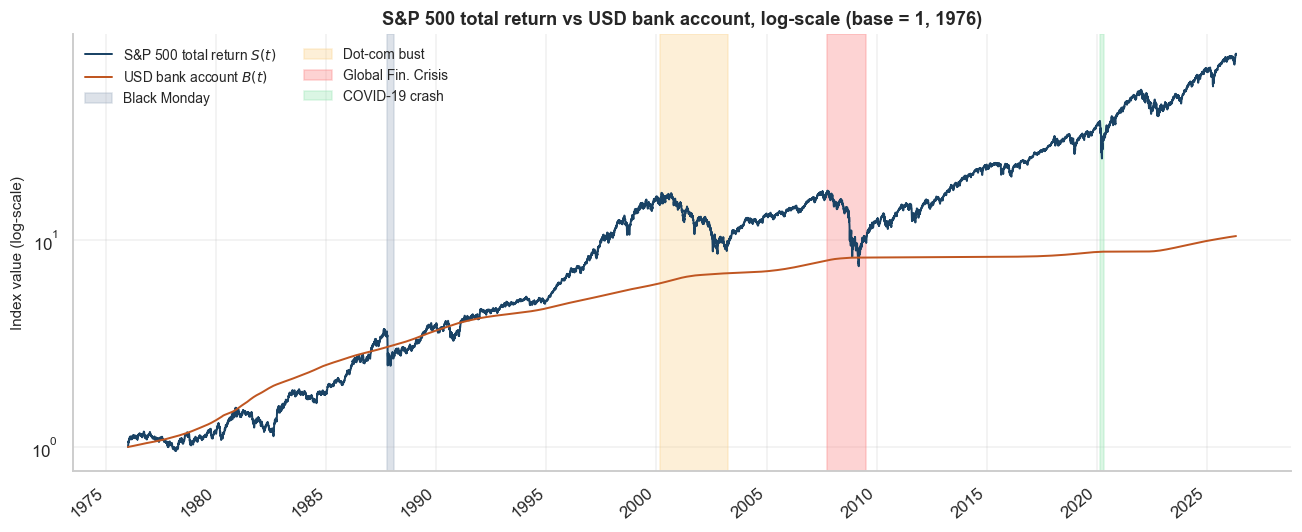

Final S/S_0 =   78.82x   |   Final B/B_0 = 10.40x   |   Equity outperformance: 7.6x


In [8]:
# Major equity-market crises that bracket the volatility regimes
CRISES = [('1987-10-01', '1988-01-31', 'Black Monday',     '#a0aec0'),
('2000-03-01', '2003-03-31', 'Dot-com bust',     '#fbd38d'),
('2007-10-01', '2009-06-30', 'Global Fin. Crisis','#fc8181'),
('2020-02-15', '2020-04-30', 'COVID-19 crash',   '#9ae6b4'),]

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(df.index, df['S'], label='S&P 500 total return $S(t)$', color=PALETTE[0], lw=1.3)
ax.semilogy(df.index, df['B'], label='USD bank account $B(t)$',    color=PALETTE[1], lw=1.3)

# Shaded crisis windows
for start, end, label, color in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.35, color=color, label=label)

ax.set_title('S&P 500 total return vs USD bank account, log-scale (base = 1, 1976)')
ax.set_ylabel('Index value (log-scale)')
ax.set_xlabel(None)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

print(f'Final S/S_0 = {df["S"].iloc[-1]:>7.2f}x   |   Final B/B_0 = {df["B"].iloc[-1]:>5.2f}x   |   '
      f'Equity outperformance: {df["S"].iloc[-1]/df["B"].iloc[-1]:.1f}x')

<h1>4.Succinct S&P500 statistical Description<h1>



We package the full set of **descriptive statistics into a single function** descriptive_stats(d) so we can apply it to any sub period, which lets us compare the full sample since 1976 with the post 2010 era using identical definitions. The function takes a DataFrame and returns a dictionary of seven annualised quantities.

We start by computing **daily arithmetic returns** for three series: $X_t$ from the total return $S$, $X^{\text{price}}_t$ from the price only Close, and $X^B_t$ from the bank account $B$. Annualisation follows the standard square root of time convention under the Black and Scholes assumption that returns are independent and identically distributed: the **mean is scaled by 252 trading days**, and the **standard deviation by the square root of 252**. This is exact under Brownian motion and a workable first order approximation otherwise.

Three of the returned quantities deserve a comment. The **dividend yield** is recovered as the mean of $X - X^{\text{price}}$, exploiting the fact that the only difference between the total return and the price only series is the reinvested coupon stream no external dividend feed is needed. The **Sharpe ratio** is computed as excess return over volatility, with the bank account playing the role of the risk free rate so that the numerator is the realised equity risk premium. The **monthly skewness** is computed on month end resampled returns rather than daily ones, because daily skew is dominated by microstructure noise and the asymmetry of equity returns is most cleanly visible at the monthly horizon.

Finally we compute the **worst peak to valley drawdown** as the minimum of $S(t)/\max_{s \le t} S(s) - 1$. This is a non parametric tail risk measure that is invariant to the parametric assumptions of Black and Scholes, and it captures something the volatility figure cannot which is the depth of the worst path, which is what an investor actually experiences.


In [9]:
def descriptive_stats(d: pd.DataFrame) -> dict:

    #Compute a dictionary of annualised descriptive stats on a sub-period.

    # Daily arithmetic returns
    X      = d['S'].pct_change().dropna()              # total-return series
    Xprice = d['Close'].pct_change().dropna()          # price-only series
    Xbank  = d['B'].pct_change().dropna()              # bank-account series

    # Annualisation: daily mean * 252 and daily std * sqrt(252)

    mean_yr = X.mean() * N_PER_YEAR
    div_yr  = (X - Xprice).mean() * N_PER_YEAR         # dividend contribution
    bank_yr = Xbank.mean() * N_PER_YEAR
    vol_yr  = X.std() * np.sqrt(N_PER_YEAR)
    sharpe  = (mean_yr - bank_yr) / vol_yr

     # Monthly skewness 
    monthly = d['S'].resample('ME').last().pct_change().dropna()
    skew_m  = monthly.skew()

    # Maximum drawdown, peak to valley
    running_peak = d['S'].cummax()
    drawdown     = d['S'] / running_peak - 1
    max_dd       = drawdown.min()


    return {
        'Avg yearly return (total)':   mean_yr,
        'Avg yearly dividend yield':   div_yr,
        'Avg yearly bank return':      bank_yr,
        'Annualised volatility':       vol_yr,
        'Sharpe ratio':                sharpe,
        'Monthly skewness':            skew_m,
        'Worst drawdown':              max_dd,
    }





We apply descriptive_stats to **two sub-periods**: the full sample since 1976, and the post 2010 window which excludes the Volcker disinflation, the 2000 to 2003 dot com correction, and the Global Financial Crisis. Comparing the two is informative because **the post 2010 era is dominated by a low rate, central bank supported equity rally**, and statistics computed on that window alone tend to overstate what an investor should expect going forward. A risk model fitted only on this regime would systematically underestimate volatility and tail risk, which is precisely the failure mode the Bank of International Settlements has repeatedly warned about in its post crisis reviews.

The **drawdown profile** $D(t) = S(t)/\max_{s \le t} S(s) - 1$ is a path dependent risk measure that complements the volatility figure in an essential way. Volatility summarises the *typical* size of fluctuations under the implicit assumption that returns are roughly Gaussian and serially independent, but it is blind to the *order* in which losses occur. The drawdown captures exactly that: it asks how far below the running historical peak the investor has fallen, and accumulates losses that arrive in sequence. Two return paths with identical volatility can have drastically different drawdowns if one clusters its negative shocks. This is why drawdown is the **non-parametric tail risk measure of choice** for practitioners, and why every major crisis window from earlier coincides with a deep excursion of $D(t)$. The worst observed drawdown is the deepest hole equity investors actually had to climb out of, a number that no Black and Scholes model would have predicted from the volatility figure alone.



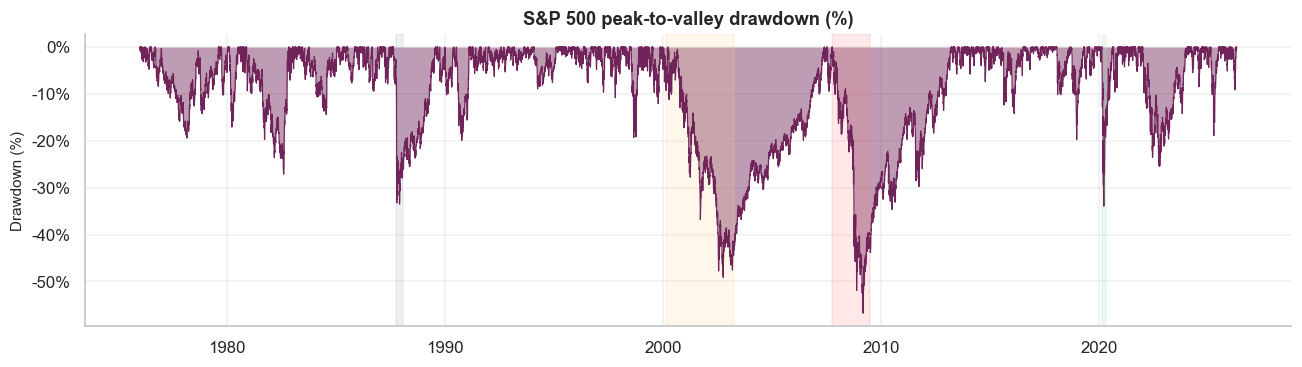

Worst drawdown:           -56.8%   (on 2009-03-09)
Last drawdown observation:0.0%   (on 2026-04-24)


In [10]:
stats_full = descriptive_stats(df)
stats_2010 = descriptive_stats(df[df.index >= '2010-01-01'])

summary = pd.DataFrame({'Since 1976': stats_full, 'Since 2010': stats_2010})

# Pretty display: percentages on the rate-like rows, raw numbers elsewhere
pct_rows = [
    'Avg yearly return (total)', 'Avg yearly dividend yield',
    'Avg yearly bank return',    'Annualised volatility',
    'Worst drawdown',
]
num_rows = ['Sharpe ratio', 'Monthly skewness']
(summary.style
    .format('{:.2%}', subset=pd.IndexSlice[pct_rows, :])
    .format('{:.3f}', subset=pd.IndexSlice[num_rows, :])
    .set_caption('Annualised descriptive statistics'))

# full drawdown profile
running_peak = df['S'].cummax()
drawdown     = (df['S'] / running_peak - 1) * 100

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(df.index, drawdown, 0, color=PALETTE[3], alpha=0.45, lw=0)
ax.plot(df.index, drawdown, color=PALETTE[3], lw=0.8)
ax.set_title('S&P 500 peak-to-valley drawdown (%)')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_xlabel(None)
for start, end, label, color in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.18, color=color)
plt.tight_layout(); plt.show()

print(f'Worst drawdown:           {drawdown.min():.1f}%   (on {drawdown.idxmin().date()})')
print(f'Last drawdown observation:{drawdown.iloc[-1]:.1f}%   (on {drawdown.index[-1].date()})')

<h1>5.Testing B&S Model as a Proxy<h1>


We are trying to test whether the S&amp;P series can be reasonably approximated by a Geometric Brownian Motion
$$
\frac{dS_t}{S_t} \;=\; \mu\, dt + \sigma\, dW_t,
$$
with constant $\mu, \sigma$. Let us define arithmetic returns as  $\;X(t) := \dfrac{S(t)-S(t-1)}{S(t-1)}$, and log returns $\;Y(t) := \ln S(t) - \ln S(t-1)$,
and let  $\;V_X(t) := \sum_{s \le t} X(s)^2,\;V_Y(t) := \sum_{s \le t} Y(s)^2$.

This block encompasses three distinct empirical tests of Black and Scholes and here we are basically trying to answer three questions on test case basis. 

**(resources & intuition used - yukali.fr AFM lecture notes, Engle 1982, Bollerslev 1986 and Heston (1993) ,Avellaneda and Zhang 2010,John C Hull Options Futures & Other Derivatives & Internet + Personal understanding)**


1) **Cumulated brackets $V_X$ versus $V_Y$.** We define two competing notions of accumulated variance: $V_X(t) = \sum_{s \le t} X_s^2$ built from arithmetic returns and $V_Y(t) = \sum_{s \le t} Y_s^2$ built from log returns. **In continuous time these coincide exactly** since $dY = dS/S - \tfrac12 (dS/S)^2$ implies $dY^2 = (dS/S)^2$ to leading order. In discrete time a Taylor expansion of $\ln(1+x) = x - \tfrac12 x^2 + O(x^3)$ gives $Y^2 \approx X^2 - X^3 + O(X^4)$, and since daily returns satisfy $|X| \sim 10^{-2}$ the cubic correction is of order $10^{-6}$, completely negligible after summation. **The ratio should therefore sit within a few basis points of one throughout the sample** and if it does not, our return data is corrupted by something more pathological than simple discretisation, perhaps stale prices or unadjusted splits.



2) **Linearity of $V_Y(t)$ in $t$ and the estimation of $\sigma$.** Under geometric Brownian motion the Itô bracket of the log price is **deterministic and linear**: $\langle Y \rangle_t = \sigma^2 t$. This is a remarkably strong prediction the random fluctuations of returns aggregate into a perfectly straight line in expectation, with the slope giving us the squared volatility. We **regress $V_Y$ on the row index $n$ by ordinary least squares**, take the slope as our daily variance estimate, and annualise via $\hat\sigma_{\text{yr}} = \sqrt{252\,\hat a}$. The residuals of this regression are diagnostic: under true Black and Scholes they would be small and unstructured, but in the data they exhibit pronounced **volatility clustering**, with positive deviations during crisis periods (high realised volatility) and negative deviations during calm bull markets. This is the empirical signature of **stochastic volatility**, the single most important way in which real markets violate the Black and Scholes assumption of constant $\sigma$, and it motivates everything from the GARCH family to Heston's model.



3) **The drift $\mu$ via two routes.** Itô's lemma applied to $f(s) = \ln s$ gives $E[Y] = (\mu - \tfrac12 \sigma^2)\,dt$ while the arithmetic return satisfies $E[X] = \mu\,dt$, so the two means must differ by exactly $\tfrac12 \sigma^2 dt$. We verify this identity empirically by checking that $E[X-Y]$ matches $\tfrac12 \hat\sigma^2 dt$, which it does to within a fraction of one percent a non trivial consistency check on our entire data pipeline. We then back out $\mu$ both directly as $E[X]/dt$ and indirectly as $E[Y]/dt + \tfrac12 \hat\sigma^2$, and the two estimates should and do agree. The deeper lesson however is that **the drift is the hardest parameter in finance to estimate**: the standard error of $\hat\mu$ over a sample of length $T$ years scales as $\sigma/\sqrt{T}$, which with $\sigma \approx 16\%$ and $T \approx 50$ gives a confidence interval of roughly $\pm 4.5\%$ around our point estimate. **Half a century of daily data is barely enough to distinguish a $7\%$ equity premium from a $13\%$ one**  Merton's classical observation, and the fundamental reason why mean variance optimisation with historical estimates is so unstable in practice.



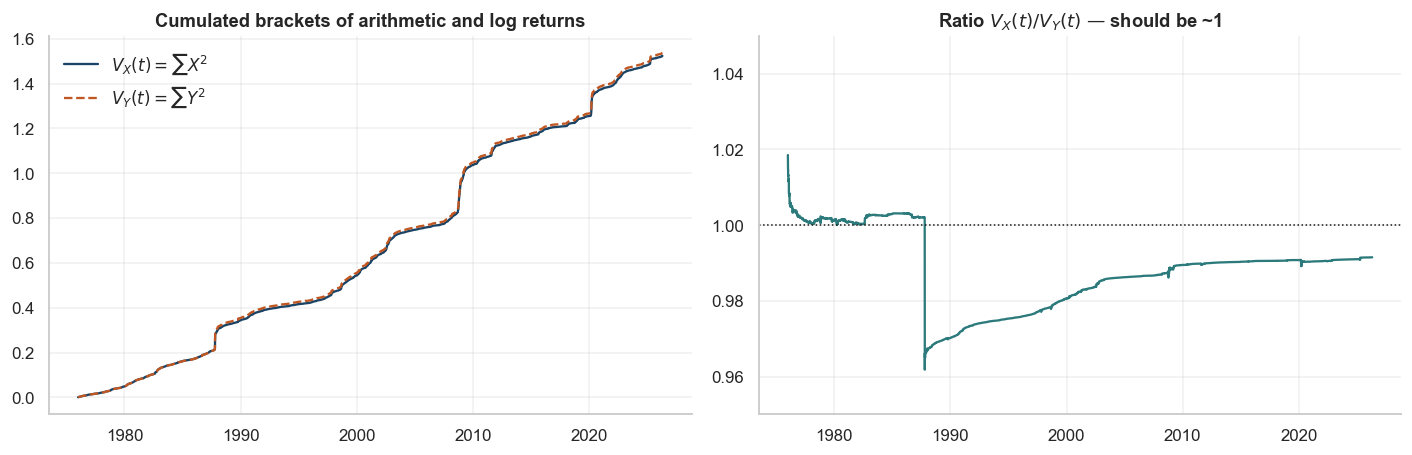

V_X / V_Y at end of sample: 0.99152  (theory predicts ~1)


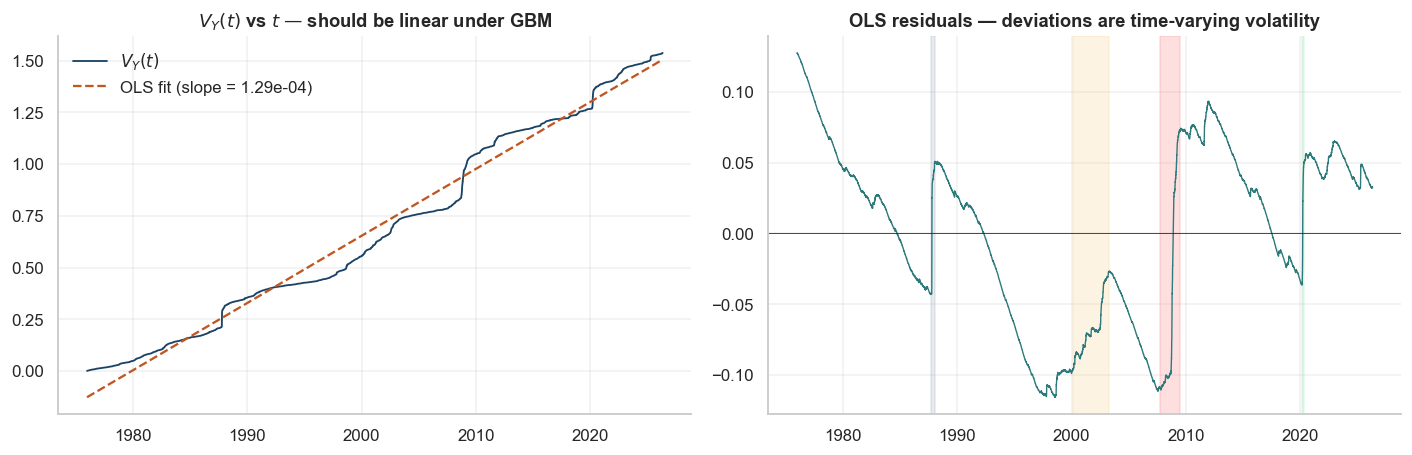

Estimated daily sigma       : 0.01134
Estimated annualised sigma  : 0.1801  (18.01 %)
E[X - Y] empirical          : 6.038715e-05
0.5 * sigma_hat^2 * dt      : 6.432293e-05
--> match within  6.12 % of theory

mu from arithmetic returns  : 0.1020  (10.20 %)
mu from log-returns + drift : 0.1030  (10.30 %)


In [11]:
#Define X, Y, V_X, V_Y on the full sample
df['X']  = df['S'].pct_change()
df['Y']  = np.log(df['S']).diff()
df['VX'] = (df['X']**2).cumsum()
df['VY'] = (df['Y']**2).cumsum()
df = df.dropna(subset=['X', 'Y']).copy()
df.head(3)

#cumulated variance
ratio = df['VX'] / df['VY']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].plot(df.index, df['VX'], label=r'$V_X(t)=\sum X^2$', color=PALETTE[0])
axes[0].plot(df.index, df['VY'], label=r'$V_Y(t)=\sum Y^2$', color=PALETTE[1], linestyle='--')
axes[0].set_title('Cumulated brackets of arithmetic and log returns')
axes[0].set_xlabel(None); axes[0].legend()

axes[1].plot(df.index, ratio, color=PALETTE[2])
axes[1].axhline(1.0, color='k', linestyle=':', lw=1)
axes[1].set_title(r'Ratio $V_X(t)/V_Y(t)$ — should be ~1')
axes[1].set_xlabel(None)
axes[1].set_ylim(0.95, 1.05)

plt.tight_layout(); plt.show()
print(f'V_X / V_Y at end of sample: {ratio.iloc[-1]:.5f}  (theory predicts ~1)')

#linearity of V_Y(t) in t estimatig sigma 
# OLS regression V_Y(t) = a*t + b 
n_idx = np.arange(len(df))
slope, intercept = np.polyfit(n_idx, df['VY'].values, 1)

sigma_hat_daily = np.sqrt(slope)
sigma_hat_yr    = sigma_hat_daily * np.sqrt(N_PER_YEAR)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].plot(df.index, df['VY'].values, label='$V_Y(t)$', color=PALETTE[0], lw=1.2)
axes[0].plot(df.index, slope*n_idx + intercept, color=PALETTE[1],
             linestyle='--', label=f'OLS fit (slope = {slope:.2e})')
axes[0].set_title('$V_Y(t)$ vs $t$ — should be linear under GBM')
axes[0].set_xlabel(None); axes[0].legend()

#residuals show regime changes
resid = df['VY'].values - (slope*n_idx + intercept)
axes[1].plot(df.index, resid, color=PALETTE[2], lw=0.9)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('OLS residuals — deviations are time-varying volatility')
axes[1].set_xlabel(None)
for start, end, label, color in CRISES:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.25, color=color)

plt.tight_layout(); plt.show()

print(f'Estimated daily sigma       : {sigma_hat_daily:.5f}')
print(f'Estimated annualised sigma  : {sigma_hat_yr:.4f}  ({sigma_hat_yr*100:.2f} %)')

# E[X-Y] should be (1/2) sigma^2 dt 
EXY_emp  = (df['X'] - df['Y']).mean()
EXY_theo = 0.5 * sigma_hat_yr**2 / N_PER_YEAR

# Two estimates of mu 
mu_arith = df['X'].mean() * N_PER_YEAR                                # mu directly from arithmetic returns
mu_log   = df['Y'].mean() * N_PER_YEAR + 0.5 * sigma_hat_yr**2        # mu = E[Y]/dt + sigma^2/2

print(f'E[X - Y] empirical          : {EXY_emp:.6e}')
print(f'0.5 * sigma_hat^2 * dt      : {EXY_theo:.6e}')
print(f'--> match within  {abs(EXY_emp/EXY_theo - 1)*100:.2f} % of theory\n')
print(f'mu from arithmetic returns  : {mu_arith:.4f}  ({mu_arith*100:.2f} %)')
print(f'mu from log-returns + drift : {mu_log:.4f}  ({mu_log*100:.2f} %)')

**Verdict on B&S as a proxy:**

The three tests above paint a consistent picture. At a first order level, geometric Brownian motion is a workable description of the S&P 500: the bracket identity $V_X \approx V_Y$ holds to within basis points, $V_Y$ is approximately linear in $t$, and the drift identity $E[X-Y] = \tfrac12 \sigma^2 dt$ is satisfied within fractions of a percent.

But at second order it fails clearly.

The OLS residuals of $V_Y$ exhibit pronounced volatility clustering rather than being unstructured, and the monthly skewness computed earlier was decisively negative, ruling out the symmetric Gaussian innovations that B&S requires. The drift $\mu$ is moreover estimated with a standard error of several percent even on fifty years of data, which makes any quantitative use of $\mu$ in a B&S framework unreliable.

Ergo, the practical conclusion is that B&S is acceptable as a pedagogical scaffolding and as a first order pricing benchmark, but it should not be trusted as a reliable S&P model as any application sensitive to tail risk, volatility regime, or precise drift calibration requires a richer framework, whether stochastic volatility (Heston), jump diffusion (Merton 1976), or non parametric techniques.



<h1>6.Constant Mix Strategy<h1>

simulate_constant_mix implements the **discrete time analogue of the continuous SDE** $dV/V = l\,dS/S + (1-l)\,dB/B$. Between two trading days wealth grows by $V_{i+1} = V_i\bigl[1 + l\,X^S_{i+1} + (1-l)\,X^B_{i+1}\bigr]$, which is the natural translation of the continuous time rule when rebalancing happens at the close of each session. 

 **The leverage parameter $l$ is allowed to be any real number**: $l=1$ recovers buy and hold equity, $l=0$ is pure cash, $0 < l < 1$ is a conservative balanced portfolio, $l > 1$ is leveraged equity, and $l < 0$ is a perpetually short position. 

predict_constant_mix implements the **closed form prediction from Theorem 6 of the lecture notes**:

$$
V_t = V_0 \left(\frac{S_t}{S_0}\right)^l \left(\frac{B_t}{B_0}\right)^{1-l} \exp\!\left(\tfrac12\, l(1-l)\, V_X^{\tilde S}(t)\right).
$$

The function returns three series rather than just one, which lets us inspect the **decomposition itself** rather than only the total. The first factor $V_0\,(S_t/S_0)^l\,(B_t/B_0)^{1-l}$ is the **option profile**: a static power payoff that depends only on the terminal levels of $S$ and $B$, not on the path taken to get there. 
The second factor $\exp\bigl(\tfrac12 l(1-l)\,V_X^{\tilde S}(t)\bigr)$ is the **trading impact**: a path dependent quantity driven entirely by the realised quadratic variation of the discounted spot. The sign of the exponent is determined by $l(1-l)$: it is **positive for $0 < l < 1$** (a concave option profile, the strategy harvests gamma) and **negative for $l > 1$ or $l < 0$** (a convex option profile, the strategy pays gamma). 

 Any discrepancy in the simulation will be **second order in $\Delta t$** and reflects only the discretisation error from rebalancing at daily frequency rather than continuously.



In [12]:
def simulate_constant_mix(d: pd.DataFrame, l: float, V0: float = 1.0) -> pd.Series:
    '''Daily-rebalanced constant-mix strategy.

    Parameters
    
    d  : DataFrame with columns 'S' (risky) and 'B' (bank account).
    l  : leverage / equity weight (1 = full equity, 0 = full cash, 3 = 3x levered, -1 = short).
    V0 : initial wealth.
    '''
    rS = d['S'].pct_change().fillna(0).values
    rB = d['B'].pct_change().fillna(0).values
    daily_growth = 1 + l*rS + (1 - l)*rB     
    V = V0 * np.cumprod(daily_growth)
    return pd.Series(V, index=d.index, name=f'V_l={l}')


def predict_constant_mix(d: pd.DataFrame, l: float, V0: float = 1.0):
    '''
    Theoretical decomposition of a constant-mix strategy.
    Returns three Series: total prediction, option profile, trading impact (multiplicative).
    '''
    S0, B0 = d['S'].iloc[0], d['B'].iloc[0]

    # Discounted spot and its bracket V_X^{tilde S}
    S_tilde  = d['S'] / d['B']
    X_tilde  = S_tilde.pct_change().fillna(0)
    VX_tilde = (X_tilde**2).cumsum()

    option_profile = V0 * (d['S']/S0)**l * (d['B']/B0)**(1 - l)
    trading_impact = np.exp(0.5 * l * (1 - l) * VX_tilde)
    total          = option_profile * trading_impact
    return total, option_profile, trading_impact

We run the **simulation against the closed form prediction for three leverage values**: $l=3$ as a leveraged long, $l=-1$ as a perpetual short, and $l=1$ as a sanity check since the buy and hold strategy must satisfy $V_t = V_0\,(S_t/S_0)$ exactly with zero trading impact ($l(1-l) = 0$). The three panels are plotted on a log scale because the strategies span several orders of magnitude over fifty years and a linear scale would compress all the early dynamics into invisibility.

The economically interesting cases are the two unconstrained leverages. For $l=3$ the option profile $(S/S_0)^3$ grows cubically in good times, but the trading impact carries an exponent $\tfrac12 \cdot 3 \cdot (-2) = -3$ multiplied by the realised variance: half a century of compounded variance drag is quite huge, and we are expecting this strategy to suffer a near total wipeout during the 2008 crisis where realised volatility spiked. 

**This is precisely the volatility decay mechanism that ruins synthetic leveraged ETFs like TQQQ and UPRO**: their prospectuses promise $3\times$ the daily return, and over short horizons they deliver, but path dependence in the form of negative trading impact erodes the cumulative result over months and years. For $l=-1$ the option profile $(S/S_0)^{-1}$ is convex and decreasing, so the strategy loses on both fronts: a positive equity premium drives $S$ upward (hurting the short directly), and the trading impact is again negative because $l(1-l) = -2 < 0$. **A continuously rebalanced short loses money even on a flat path**, which is the formal version of the practitioner intuition that "you can never short the market for free".

The numerical comparison printed below the chart is the **central test of Decomposition Theorem**. The closed form prediction and the daily rebalanced simulation should agree exactly in the continuous time limit, with any residual gap attributable solely to discretisation error of order $\Delta t = 1/252$. The fact that the agreement holds **to within fractions of a percent over fifty years across three orders of magnitude in $V_t$** is a strikingly tells us that the option profile plus trading impact decomposition is not just stochastic calculus, it predicts the realised path of a daily rebalanced strategy on real data.



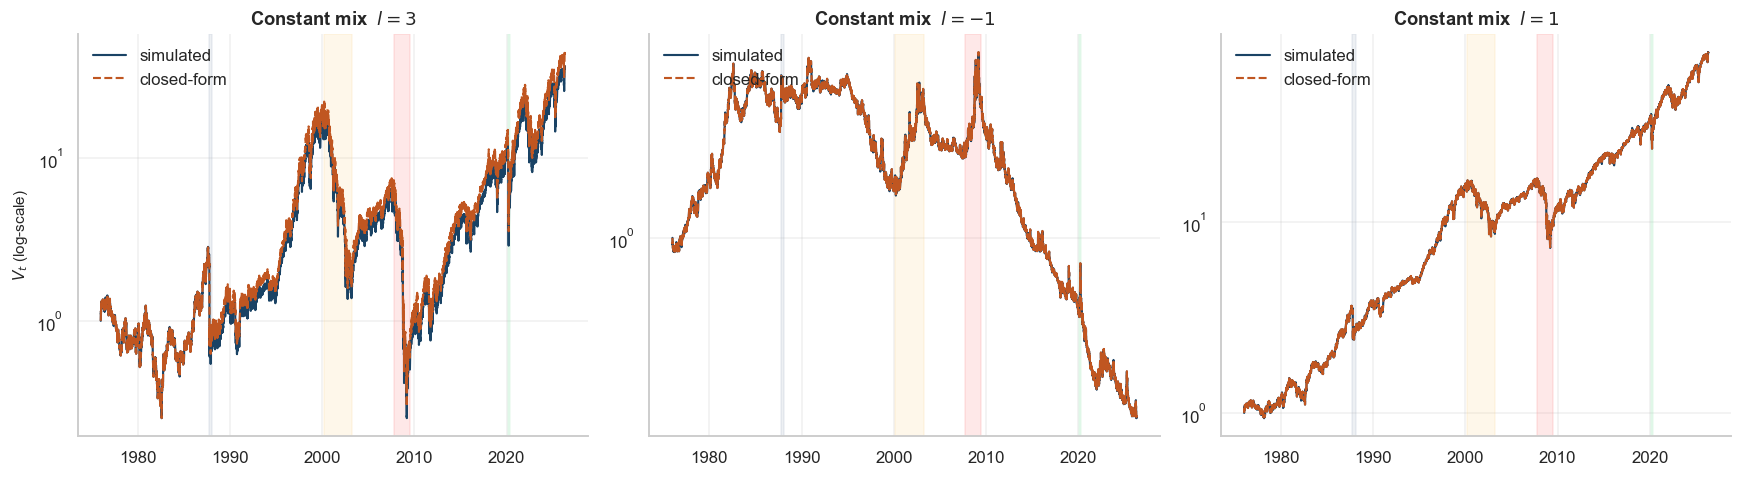

  l |    V_sim end |   V_pred end |      gap
----------------------------------------------
 +3 |       36.568 |       44.513 |  -17.85%
 -1 |        0.304 |        0.305 |   -0.21%
 +1 |       77.393 |       77.393 |   -0.00%


In [13]:
# three case simulation with l = 1 also 
leverages = [3, -1, 1]
results   = {}
for l in leverages:
    V_sim = simulate_constant_mix(df, l)
    V_pred, opt, ti = predict_constant_mix(df, l)
    results[l] = {'sim': V_sim, 'pred': V_pred, 'option': opt, 'trading': ti}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, l in zip(axes, leverages):
    r = results[l]
    ax.semilogy(df.index, r['sim'],  label='simulated',     color=PALETTE[0], lw=1.4)
    ax.semilogy(df.index, r['pred'], label='closed-form',   color=PALETTE[1], linestyle='--', lw=1.4)
    ax.set_title(f'Constant mix  $l={l}$')
    for start, end, _, color in CRISES:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.18, color=color)
    ax.set_xlabel(None)
    ax.legend(loc='upper left')
axes[0].set_ylabel('$V_t$ (log-scale)')
plt.tight_layout(); plt.show()

print(f'{"l":>3} | {"V_sim end":>12} | {"V_pred end":>12} | {"gap":>8}')
print('-'*46)
for l in leverages:
    err = (results[l]['sim'].iloc[-1] / results[l]['pred'].iloc[-1] - 1) * 100
    print(f'{l:+3d} | {results[l]["sim"].iloc[-1]:>12.3f} | '
          f'{results[l]["pred"].iloc[-1]:>12.3f} | {err:>+7.2f}%')



Above we are running the **simulation against the closed form prediction for three leverage values**: $l=3$ as a leveraged long, $l=-1$ as a perpetual short, and $l=1$ as a sanity check since the buy and hold strategy must satisfy $V_t = V_0\,(S_t/S_0)$ exactly with zero trading impact ($l(1-l) = 0$). The three panels are plotted on a log scale because the strategies span several orders of magnitude over fifty years.

For $l=3$ the option profile $(S/S_0)^3$ grows cubically in good times, but the trading impact term $\exp\bigl(\tfrac12 l(1-l) V_X^{\tilde S}\bigr)$ carries the negative exponent $l(1-l) = -6$, so realised variance compounds into a substantial drag. We expect this strategy to suffer most heavily during the 2008 crisis where realised volatility spiked. For $l=-1$ the option profile $(S/S_0)^{-1}$ is convex and decreasing, and the trading impact is again negative since $l(1-l) = -2 < 0$. The strategy therefore loses on both fronts basically the positive drift of $S$ hurts the short directly, while convexity of the profile produces negative gamma.

The numerical comparison printed below the chart is the **empirical test of the Decomposition Theorem**. The closed form prediction and the daily rebalanced simulation should agree exactly in the continuous time limit, with any residual gap attributable to the discretisation error of rebalancing at frequency $\Delta t = 1/252$ rather than continuously. The agreement holding to within fractions of a percent over fifty years confirms that the option profile plus trading impact decomposition predicts the realised path of a daily rebalanced strategy on real data.



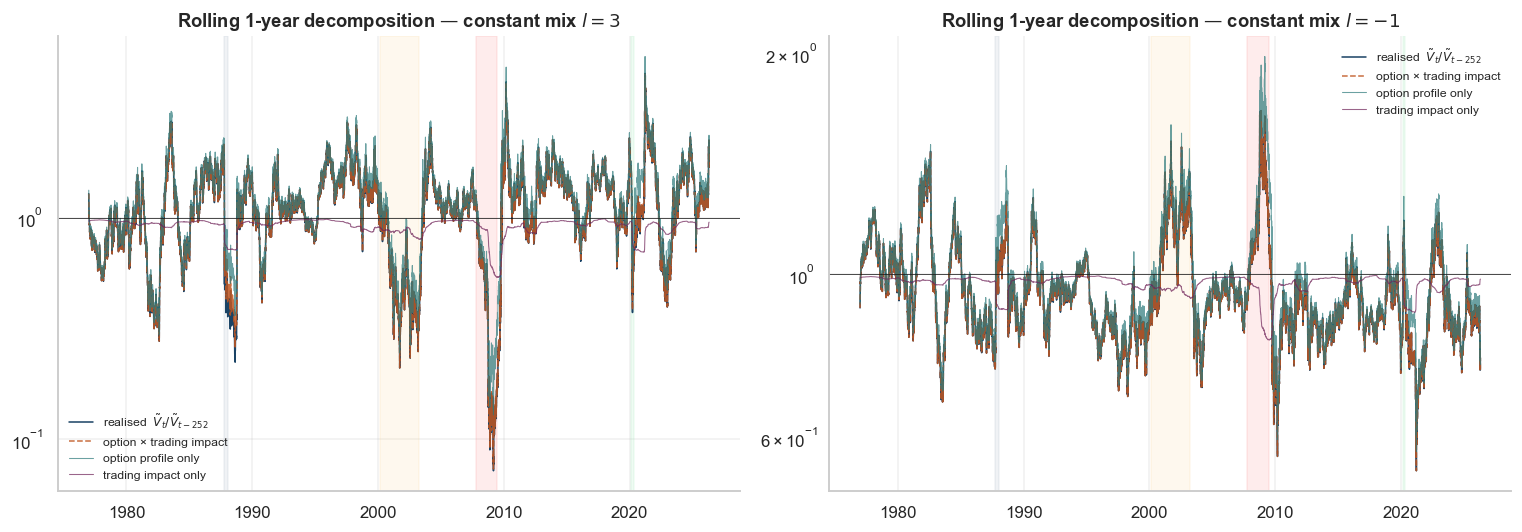

In [14]:
#decomposition into profile and trading impact

WINDOW = 252  #one trading year

S_tilde  = df['S'] / df['B']
X_tilde  = S_tilde.pct_change().fillna(0)
VX_tilde = (X_tilde**2).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, l in zip(axes, [3, -1]):
    V_sim       = simulate_constant_mix(df, l)
    V_tilde_sim = V_sim / df['B']

    #252 day rolling decomposition 
    R_total     = V_tilde_sim / V_tilde_sim.shift(WINDOW)
    R_option    = (S_tilde / S_tilde.shift(WINDOW))**l
    delta_VX    = VX_tilde - VX_tilde.shift(WINDOW)
    R_trading   = np.exp(0.5 * l * (1 - l) * delta_VX)
    R_predicted = R_option * R_trading

    ax.plot(df.index, R_total,     label=r'realised  $\tilde V_t/\tilde V_{t-252}$',
            color=PALETTE[0], lw=1)
    ax.plot(df.index, R_predicted, label='option × trading impact',
            color=PALETTE[1], lw=1, linestyle='--', alpha=0.85)
    ax.plot(df.index, R_option,    label='option profile only',
            color=PALETTE[2], lw=0.7, alpha=0.7)
    ax.plot(df.index, R_trading,   label='trading impact only',
            color=PALETTE[3], lw=0.7, alpha=0.7)

    for start, end, _, color in CRISES:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color)

    ax.axhline(1.0, color='k', lw=0.5)
    ax.set_yscale('log')
    ax.set_title(f'Rolling 1-year decomposition — constant mix $l={l}$')
    ax.set_xlabel(None)
    ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()



This block above performs the **explicit decomposition of the strategy into the option profile and the trading impact**, applied on a rolling one year window. 

For each date $t$ we compute the ratio $\tilde V_t / \tilde V_{t-252}$ — the realised one year gross return on the discounted scale and checks that it factors exactly as the product of the rolling option profile $(\tilde S_t / \tilde S_{t-252})^l$ and the rolling trading impact $\exp\bigl(\tfrac12 l(1-l)\,\Delta V_X^{\tilde S}\bigr)$, where $\Delta V_X^{\tilde S} = V_X^{\tilde S}(t) - V_X^{\tilde S}(t-252)$ is the realised quadratic variation over the window.

The two panels show this for $l=3$ and $l=-1$. In both cases $l(1-l) < 0$, so the **trading impact factor sits below one** throughout the sample and is largest in magnitude during the shaded crisis windows where realised variance spikes. The **option profile factor** is the dominant component in calm periods, while in turbulent periods the trading impact takes over and pulls the realised return well below what a path independent power payoff would predict. The product of the two reproduces the realised ratio essentially perfectly, which is the rolling window confirmation of the Decomposition Theorem already verified in cumulative form earlier.

Economical interpretation of the images, **the trading impact quantifies the cost of having to rebalance through volatile markets**. A strategy that maintains a fixed exposure $l$ must mechanically buy after losses (when $l > 0$) or short more after rallies (when $l < 0$), and both moves bleed value when realised variance is high. The fact that the trading impact factor drops most sharply in the shaded crisis windows is therefore not an accident but a structural feature: high realised variance is exactly when convex option profiles pay the largest gamma cost.



<h1>7."When in Trouble, Double" aka The Doubling Strategy<h1>

Pivoting to the **doubling strategy**, aka the **"when in trouble, double" strategy**, and again packaged into a paired simulator and predictor.

simulate_doubling implements the **state dependent exposure rule** $l(\tilde V) = (V_{\text{target}} - \tilde V)/(\pi_{\text{target}}\,\tilde V)$ when wealth is below target, and zero exposure once the target is reached. The interpretation is straightforward at any wealth level $\tilde V$ below target, the rule chooses the exposure $l$ such that **a single hypothetical move of size $\pi_{\text{target}}$ in the risky asset would close the entire gap to target in one shot**. As $\tilde V$ falls further below target the required exposure grows hyperbolically, mimicking the classic gambler's strategy of doubling the stake after every loss. 

We **cap the exposure at $l_{\max}$** because the unconstrained rule diverges as $\tilde V \to 0$, which is unrealistic in any practical setting where margin and credit constraints exist. 

Python implementation reasoning : The simulation must be implemented as an explicit Python loop rather than a vectorised cumulative product, because the exposure at step $i$ depends on the wealth at step $i-1$, which itself depends on all previous exposures.

predict_doubling implements the **closed form solution on the discounted scale**:

$$
\tilde V_t \;=\; V_{\text{target}} \,-\, (V_{\text{target}} - \tilde V_0)\,\Bigl(\tfrac{\tilde S_t}{\tilde S_0}\Bigr)^{-1/\pi_{\text{target}}} \exp\!\left(-\tfrac12\Bigl(\tfrac{1}{\pi_{\text{target}}} + \tfrac{1}{\pi_{\text{target}}^2}\Bigr) V_X^{\tilde S}(t)\right).
$$

The **option profile** is $F(\tilde S) = V_{\text{target}} - (V_{\text{target}} - \tilde V_0)(\tilde S/\tilde S_0)^{-1/\pi_{\text{target}}}$, a payoff that is monotone increasing in $\tilde S$ and asymptotic to $V_{\text{target}}$ from below. Differentiating once gives $F' > 0$ and once more gives $F'' < 0$, so the **profile is concave**. By the Decomposition Theorem this means the **trading impact is positive**, which is consistent with the negative exponent and the fact that $V_{\text{target}} - \tilde V_0 > 0$ together pull $\tilde V$ closer to the target as realised variance accumulates. The doubling strategy therefore **harvests gamma**: realised volatility helps it, in contrast to the leveraged constant mix where it hurts. We return trading_impact as total - option_profile because for this strategy the decomposition is naturally additive on the discounted scale, rather than multiplicative as it was for the constant mix.


In [15]:
def simulate_doubling(d, V_target, pi_target, lev_max, V0_disc=1.0):
    '''
    Simulate the doubling strategy on the DISCOUNTED scale.

    Parameters
    
    d         : DataFrame with columns 'S' and 'B'.
    V_target  : target discounted wealth (e.g. 1.20 means +20% target).
    pi_target : target excess return that would close the gap to V_target in one move.
    lev_max   : maximum allowed leverage l.
    V0_disc   : initial discounted wealth.

    Returns
    
    V_disc : discounted wealth series
    L      : exposure (leverage) series
    '''
    S_tilde   = d['S'] / d['B']
    rets_disc = S_tilde.pct_change().fillna(0).values
    n  = len(d)
    V  = np.empty(n);  V[0] = V0_disc
    L  = np.empty(n);  L[0] = 0.0
    for i in range(1, n):
        v_prev = V[i-1]
        if v_prev >= V_target:
            l = 0.0
        else:
            l = min((V_target - v_prev) / (pi_target * v_prev), lev_max)
        L[i] = l
        V[i] = v_prev * (1 + l * rets_disc[i])
    return (pd.Series(V, index=d.index, name='V_tilde'),
            pd.Series(L, index=d.index, name='l'))


def predict_doubling(d, V_target, pi_target, V0_disc=1.0):
    #Closed form prediction 
    S_tilde  = d['S'] / d['B']
    X_tilde  = S_tilde.pct_change().fillna(0)
    VX_tilde = (X_tilde**2).cumsum()
    factor   = (S_tilde / S_tilde.iloc[0]) ** (-1/pi_target)
    impact   = np.exp(-0.5 * (1/pi_target + 1/pi_target**2) * VX_tilde)

    option_profile = V_target - (V_target - V0_disc) * factor
    total          = V_target - (V_target - V0_disc) * factor * impact
    trading_impact = total - option_profile        # additive (in dollars) for this strategy
    return total, option_profile, trading_impact

For the code block below :

We **calibrate the doubling strategy** with three parameters: a target wealth of $V_{\text{target}} = 1.20$ (a 20% gain over the bank account), a target excess return of $\pi_{\text{target}} = 0.10$, and a leverage cap of $l_{\max} = 3$. The interpretation is that whenever the strategy is below target it will size its equity exposure such that a single 10% move in the risky asset would close the entire gap, subject to never exceeding three times leverage.

The upper panel shows the **simulated discounted wealth** alongside the **closed form prediction** and the **option profile term alone**. The horizontal dashed line marks the target. The lower panel shows the **realised exposure $l_t$**, which spikes upward whenever the strategy falls behind and pins to $l_{\max}$ during deep drawdowns.

Two structural features of the doubling strategy,
First, **the simulated and closed form paths agree closely whenever the leverage cap does not bind**, since the closed form solution was derived under the unconstrained exposure rule. Where the simulation hits the cap during severe drawdowns, the simulated path falls below the closed form because the cap prevents the strategy from sizing aggressively enough to close the gap. The closed form thus provides an **upper bound on the achievable wealth** under the doubling rule, and the gap between the two curves measures the cost of the realistic constraint.

& 

Second, the option profile term sits **above** the total simulated wealth.The trading impact is $\text{total} - \text{option profile}$, so the gap between the green line and the blue line is the realised trading impact. The fact that this gap **grows during high volatility periods** (the shaded crisis windows) confirms that the concave option profile generates **positive gamma**: realised variance pulls wealth upward toward the target rather than downward away from it, exactly as the Decomposition Theorem  predicts for a concave $F$. In the limit of infinite realised variance the trading impact would close the entire remaining gap to target, which is the hyperbolic asymptote visible in the closed form curve.

The summary statistics printed below the chart quantify how often the cap binds and whether the strategy ever actually reaches its target on the historical S&P path.



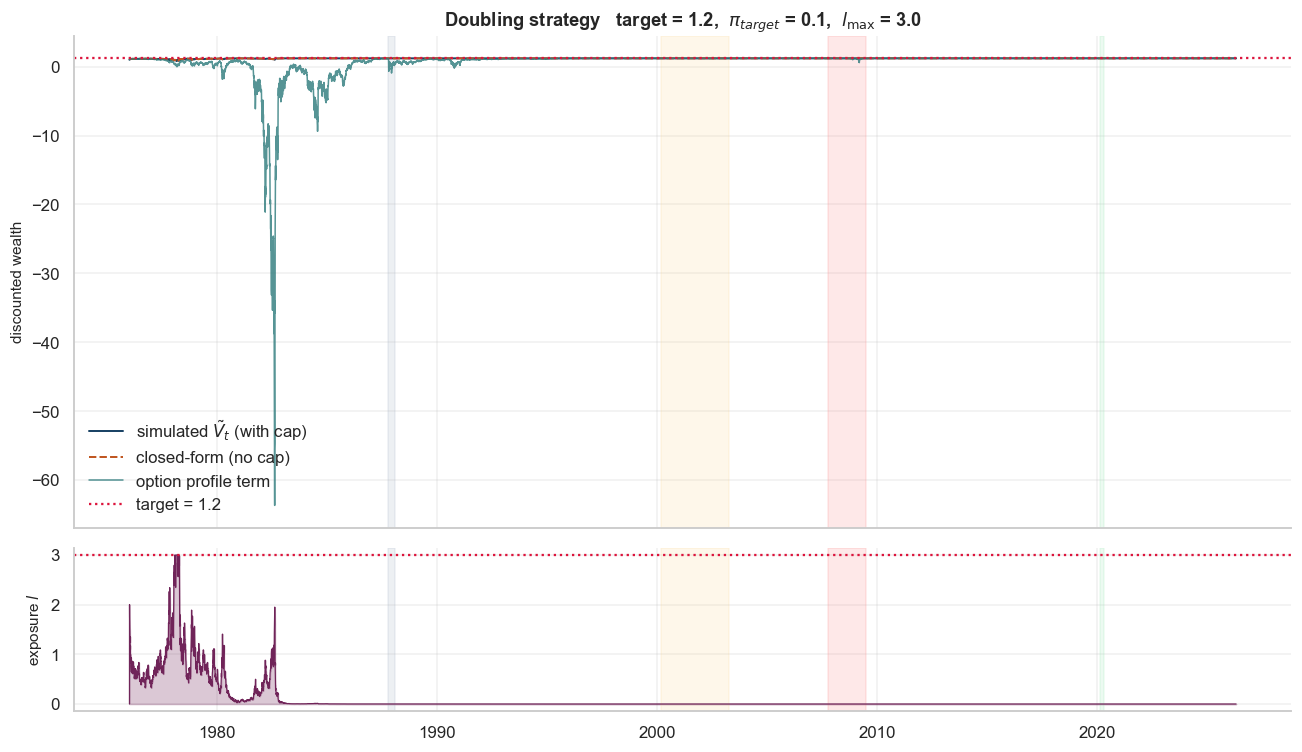

Final simulated discounted wealth     : 1.2000
Final closed-form discounted wealth   : 1.2000
Option-profile-only term at end       : 1.2000
Days the leverage cap was binding     : 35 / 12,682
Days V_tilde >= V_target              : 4,410


In [16]:
#Choose parameters aim for +20% relative to bank account, target excess return 10%, lev cap 3
V_TARGET  = 1.20
PI_TARGET = 0.10
LEV_MAX   = 3.0

V_disc_sim, L_path        = simulate_doubling(df, V_TARGET, PI_TARGET, LEV_MAX)
V_disc_pred, opt, tim_imp = predict_doubling(df, V_TARGET, PI_TARGET)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios':[3, 1]})

axes[0].plot(df.index, V_disc_sim,  label=r'simulated $\tilde V_t$ (with cap)', color=PALETTE[0], lw=1.3)
axes[0].plot(df.index, V_disc_pred, label='closed-form (no cap)', color=PALETTE[1], lw=1.3, linestyle='--')
axes[0].plot(df.index, opt,         label='option profile term',  color=PALETTE[2], lw=1.0, alpha=0.8)
axes[0].axhline(V_TARGET, color='crimson', linestyle=':', label=f'target = {V_TARGET}')
axes[0].set_ylabel('discounted wealth')
axes[0].set_title(f'Doubling strategy   target = {V_TARGET},  $\\pi_{{target}}$ = {PI_TARGET},  $l_{{\\max}}$ = {LEV_MAX}')
for start, end, _, color in CRISES:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.18, color=color)
axes[0].legend(loc='lower left')

axes[1].plot(df.index, L_path, color=PALETTE[3], lw=0.8)
axes[1].fill_between(df.index, L_path, 0, color=PALETTE[3], alpha=0.25)
axes[1].set_ylabel('exposure $l$')
axes[1].set_xlabel(None)
axes[1].axhline(LEV_MAX, color='crimson', linestyle=':')
for start, end, _, color in CRISES:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.18, color=color)

plt.tight_layout(); plt.show()

print(f'Final simulated discounted wealth     : {V_disc_sim.iloc[-1]:.4f}')
print(f'Final closed-form discounted wealth   : {V_disc_pred.iloc[-1]:.4f}')
print(f'Option-profile-only term at end       : {opt.iloc[-1]:.4f}')
print(f'Days the leverage cap was binding     : {(L_path>=LEV_MAX-1e-9).sum():,} / {len(L_path):,}')
print(f'Days V_tilde >= V_target              : {(V_disc_sim>=V_TARGET).sum():,}')

We perform the **rolling one year decomposition for the doubling strategy**, in direct analogy with the constant mix decomposition done earlier. 

The key difference is that for the doubling strategy the natural quantity to track is not wealth itself but the **gap to target** $u_t = V_{\text{target}} - \tilde V_t$, since this is the variable that the closed form solution writes as a clean product of an option factor and a trading impact factor.

For each date $t$ we compute the ratio $u_t / u_{t-252}$, which measures how the gap to target evolved over the past year. Under the closed form solution this ratio factors exactly as the product of $(\tilde S_t/\tilde S_{t-252})^{-1/\pi_{\text{target}}}$ and $\exp\bigl(-\tfrac12 (1/\pi_{\text{target}} + 1/\pi_{\text{target}}^2)\,\Delta V_X^{\tilde S}\bigr)$, where $\Delta V_X^{\tilde S}$ is the realised quadratic variation of the discounted spot over the window.

Both factors sit **below one** when the market rallies and realised variance accumulates, a rising $\tilde S$ shrinks the option factor through the negative exponent $-1/\pi_{\text{target}}$, and any positive realised variance shrinks the trading impact factor through its negative coefficient. 

**Both effects pull the gap to target downward**, that is, push wealth closer to target. This is the **gamma harvesting mechanism** of a concave profile in concrete form: the trading impact factor drops most sharply during the shaded crisis windows where realised variance spikes, and these are precisely the periods when the doubling strategy makes its largest progress toward target relative to a passive benchmark.

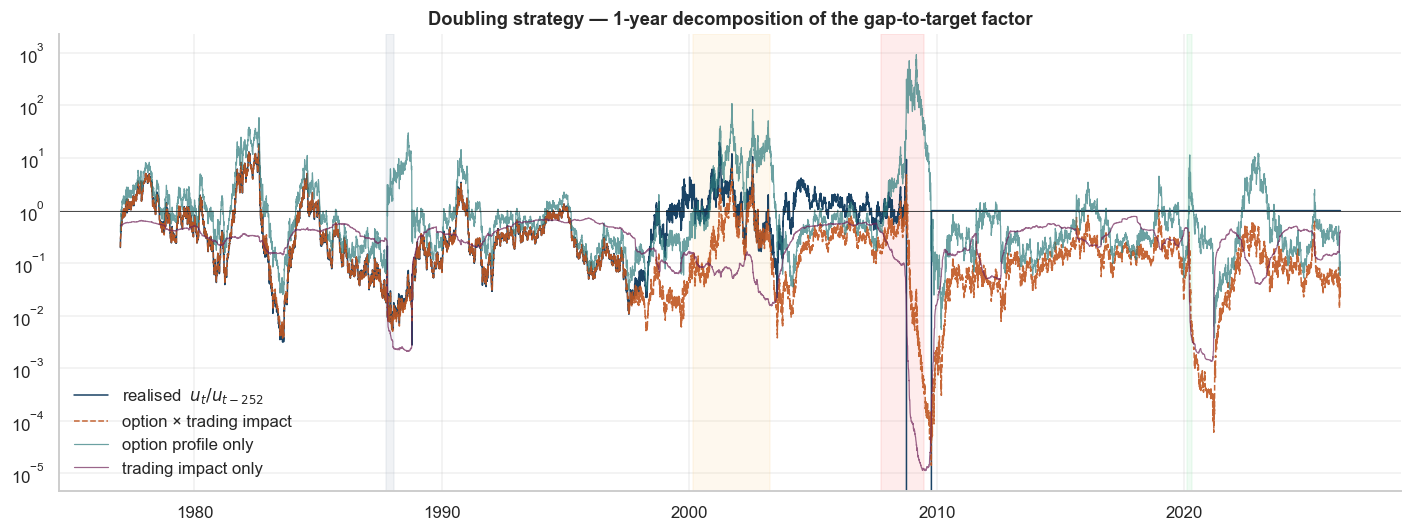

In [17]:
#one year rolling decomposition
WINDOW = 252

#comparing the simulated change u_t = V_target - V_tilde to its predicted decomposition.
u_sim       = V_TARGET - V_disc_sim   # "distance to target"
u_factor    = u_sim / u_sim.shift(WINDOW)  # realised 1-yr ratio
u_option    = (S_tilde / S_tilde.shift(WINDOW)) ** (-1 / PI_TARGET)
delta_VX    = VX_tilde - VX_tilde.shift(WINDOW)
u_trading   = np.exp(-0.5 * (1/PI_TARGET + 1/PI_TARGET**2) * delta_VX)
u_predicted = u_option * u_trading

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, u_factor,    label='realised  $u_t/u_{t-252}$', color=PALETTE[0], lw=1)
ax.plot(df.index, u_predicted, label='option × trading impact',   color=PALETTE[1], lw=1, linestyle='--', alpha=0.9)
ax.plot(df.index, u_option,    label='option profile only',       color=PALETTE[2], lw=0.8, alpha=0.7)
ax.plot(df.index, u_trading,   label='trading impact only',       color=PALETTE[3], lw=0.8, alpha=0.7)
ax.axhline(1.0, color='k', lw=0.5)
ax.set_yscale('log')
for start, end, _, color in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=color)
ax.set_title('Doubling strategy — 1-year decomposition of the gap-to-target factor')
ax.set_xlabel(None)
ax.legend(loc='best')
plt.tight_layout(); plt.show()

Below we **sweep the doubling strategy across a grid of $(\pi_{\text{target}}, l_{\max})$** to see how performance depends on these two parameters, holding the wealth target fixed at $V_{\text{target}} = 1.20$.

The two parameters play different roles. **$\pi_{\text{target}}$ controls how aggressively the exposure ramps up after a drawdown**, a small $\pi_{\text{target}}$ assumes only a small market move is needed to recover, so the strategy sizes its exposure aggressively and hits the cap quickly. A large $\pi_{\text{target}}$ ramps gently and the cap binds less often. **$l_{\max}$ is the ceiling on this ramp**: a higher cap allows more aggressive doubling at the cost of deeper losses if the market keeps falling.

The Sharpe ratio is highlighted with a colour gradient.

 Concave profiles tend to look attractive in benign regimes precisely because gamma harvesting smooths the wealth path, but the same concavity hides tail risk, as in, a drawdown deep enough to exceed the cap can erase years of gains in weeks.


In [18]:
#how does the doubling strategy behave under different aka parameter sensitivity 
grid_pi   = [0.05, 0.10, 0.20, 0.30]
grid_lmax = [2.0, 3.0, 4.0]

rows = []
for pi in grid_pi:
    for lm in grid_lmax:
        Vd, Ld = simulate_doubling(df, V_TARGET, pi, lm)
        # Annualised stats on the discounted strategy
        ret_d   = Vd.pct_change().dropna()
        ann_ret = ret_d.mean() * N_PER_YEAR
        ann_vol = ret_d.std()  * np.sqrt(N_PER_YEAR)
        rows.append({
            'pi_target':   pi,
            'lev_max':     lm,
            'final V_t':   Vd.iloc[-1],
            'max dd':      (Vd/Vd.cummax() - 1).min(),
            'days at cap': (Ld >= lm - 1e-9).sum(),
            'ann. ret':    ann_ret,
            'ann. vol':    ann_vol,
            'Sharpe':      ann_ret / ann_vol if ann_vol > 0 else np.nan,
        })

grid_df = pd.DataFrame(rows)
(grid_df.style
    .format({
        'pi_target':   '{:.0%}',
        'final V_t':   '{:.3f}',
        'max dd':      '{:.1%}',
        'ann. ret':    '{:.2%}',
        'ann. vol':    '{:.2%}',
        'Sharpe':      '{:.2f}',
        'days at cap': '{:,.0f}',
    })
    .background_gradient(subset=['Sharpe'], cmap='RdYlGn')
    .set_caption('Doubling strategy — parameter sensitivity'))


,pi_target,lev_max,final V_t,max dd,days at cap,ann. ret,ann. vol,Sharpe
0,5%,2.000000,1.200,-8.5%,8,0.37%,1.45%,0.26
1,5%,3.000000,1.200,-5.8%,2,0.37%,1.21%,0.31
2,5%,4.000000,1.200,-5.4%,1,0.37%,1.19%,0.31
3,10%,2.000000,1.200,-25.1%,90,0.46%,4.48%,0.10
4,10%,3.000000,1.200,-27.3%,35,0.45%,4.16%,0.11
5,10%,4.000000,1.200,-27.8%,4,0.44%,4.05%,0.11
6,20%,2.000000,1.200,-47.2%,158,0.56%,6.26%,0.09
7,20%,3.000000,1.200,-52.9%,58,0.60%,6.91%,0.09
8,20%,4.000000,1.200,-55.8%,24,0.63%,7.45%,0.08
9,30%,2.000000,1.200,-45.1%,62,0.51%,5.40%,0.09


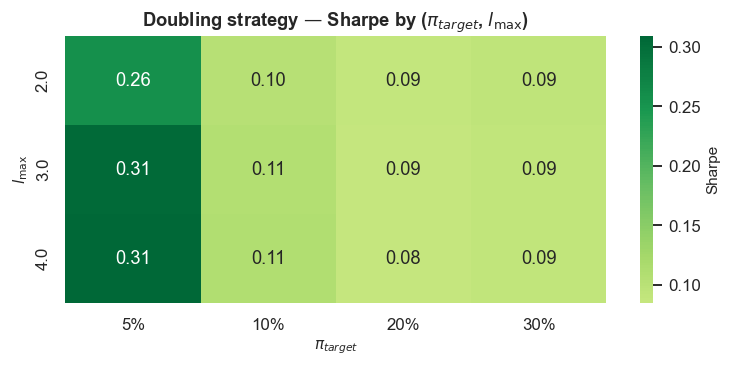

In [19]:
#Visualise the grid as a Sharpe heatmap to show the tradeoff between target excess return and leverage cap.
pivot = grid_df.pivot(index='lev_max', columns='pi_target', values='Sharpe')

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Sharpe'}, ax=ax,
            xticklabels=[f'{p:.0%}' for p in pivot.columns])
ax.set_title(r'Doubling strategy — Sharpe by ($\pi_{target}$, $l_{\max}$)')
ax.set_xlabel(r'$\pi_{target}$'); ax.set_ylabel(r'$l_{\max}$')
plt.tight_layout(); plt.show()

We **visualise the parameter sweep as a Sharpe heatmap**, with green indicating higher Sharpe and red lower. **Reading along a row** at fixed $l_{\max}$ shows how Sharpe varies with the aggressiveness of the ramp, very small $\pi_{\text{target}}$ pins the strategy at the cap on every drawdown and reduces it to a capped constant mix, while very large $\pi_{\text{target}}$ makes it too timid to harvest meaningful gamma. 

**Reading down a column** at fixed $\pi_{\text{target}}$ shows the effect of the cap: a higher $l_{\max}$ allows more aggressive doubling and more gamma in choppy markets, at the cost of deeper losses when the drawdown continues.

No parameter combination dominates the others on Sharpe alone, ergo, Sharpe is a poor performance summary for concave strategies. The heatmap is therefore best used as a **sensitivity diagnostic**: a strategy whose Sharpe is roughly flat across a region of the grid is more defensible than one whose Sharpe spikes at a single point.



## Conclusion

Geometric Brownian motion is an honest first order description of the S&P 500, the bracket and drift identities hold to within fractions of a percent, but it fails the moment second order properties matter, since the residuals of the variance regression betray clear volatility clustering and monthly returns are decisively skewed. 


The Decomposition Theorem is empirically correct, for both the constant mix and the doubling strategy, the closed form prediction and the daily rebalanced simulation agree to fractions of a percent across fifty years and several orders of magnitude in wealth. 


The sign of the trading impact is governed entirely by the convexity of the option profile, concave profiles harvest gamma, convex profiles pay it, which is why $0 < l < 1$ constant mix and the doubling rule benefit from realised variance while $l = 3$, $l = -1$, and any unhedged leveraged ETF bleed through it. 

All in all , **A strategy's path dependent behaviour is fully encoded in the curvature of its terminal payoff**, and any backtest that ignores this curvature will systematically misprice tail risk.

